In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

def linear(x):
    return x

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [26]:
# Inisialisasi bobot dan bias dengan He Initialization
def initialize_weights(input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size):
    np.random.seed(42)
    weights_input_hidden = np.random.randn(input_size, hidden_size_1) * np.sqrt(2 / input_size)
    bias_hidden_1 = np.zeros((1, hidden_size_1))

    weights_hidden_2 = np.random.randn(hidden_size_1, hidden_size_2) * np.sqrt(2 / hidden_size_1)
    bias_hidden_2 = np.zeros((1, hidden_size_2))

    weights_hidden_3 = np.random.randn(hidden_size_2, hidden_size_3) * np.sqrt(2 / hidden_size_2)
    bias_hidden_3 = np.zeros((1, hidden_size_3))

    weights_hidden_output = np.random.randn(hidden_size_3, output_size) * np.sqrt(2 / hidden_size_3)
    bias_output = np.zeros((1, output_size))

    return weights_input_hidden, bias_hidden_1, weights_hidden_2, bias_hidden_2, weights_hidden_3, bias_hidden_3, weights_hidden_output, bias_output

# Training model BPNN dengan SGD (tanpa mini-batch)
def train_bpnn_sgd(X_train, y_train, X_val, y_val, epochs=200, learning_rate=0.001):
    input_size = X_train.shape[1]  # Sudah dalam bentuk (samples, 300)
    hidden_size_1 = 128
    hidden_size_2 = 64
    hidden_size_3 = 32
    output_size = 1

    # Inisialisasi bobot dan bias
    weights_input_hidden, bias_hidden_1, weights_hidden_2, bias_hidden_2, weights_hidden_3, bias_hidden_3, weights_hidden_output, bias_output = initialize_weights(
        input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size)

    losses_train = []
    losses_val = []

    # Training loop
    for epoch in range(epochs):
        total_loss = 0

        for i in range(len(X_train)):
            # Forward pass
            x = X_train[i].reshape(1, -1)  # (1, 300)
            y = y_train[i].reshape(1, -1)  # (1, 1)

            hidden_input_1 = np.dot(x, weights_input_hidden) + bias_hidden_1
            hidden_output_1 = relu(hidden_input_1)

            hidden_input_2 = np.dot(hidden_output_1, weights_hidden_2) + bias_hidden_2
            hidden_output_2 = relu(hidden_input_2)

            hidden_input_3 = np.dot(hidden_output_2, weights_hidden_3) + bias_hidden_3
            hidden_output_3 = relu(hidden_input_3)

            output_input = np.dot(hidden_output_3, weights_hidden_output) + bias_output
            y_pred = linear(output_input)

            # Hitung loss
            loss = mse_loss(y, y_pred)
            total_loss += loss

            # Backpropagation
            error_output = y_pred - y
            grad_weights_output = np.dot(hidden_output_3.T, error_output)
            grad_bias_output = error_output

            error_hidden_3 = np.dot(error_output, weights_hidden_output.T) * relu_derivative(hidden_input_3)
            grad_weights_hidden_3 = np.dot(hidden_output_2.T, error_hidden_3)
            grad_bias_hidden_3 = error_hidden_3

            error_hidden_2 = np.dot(error_hidden_3, weights_hidden_3.T) * relu_derivative(hidden_input_2)
            grad_weights_hidden_2 = np.dot(hidden_output_1.T, error_hidden_2)
            grad_bias_hidden_2 = error_hidden_2

            error_hidden_1 = np.dot(error_hidden_2, weights_hidden_2.T) * relu_derivative(hidden_input_1)
            grad_weights_hidden_1 = np.dot(x.T, error_hidden_1)
            grad_bias_hidden_1 = error_hidden_1

            # Update bobot dan bias (SGD)
            weights_hidden_output -= learning_rate * grad_weights_output
            bias_output -= learning_rate * grad_bias_output

            weights_hidden_3 -= learning_rate * grad_weights_hidden_3
            bias_hidden_3 -= learning_rate * grad_bias_hidden_3

            weights_hidden_2 -= learning_rate * grad_weights_hidden_2
            bias_hidden_2 -= learning_rate * grad_bias_hidden_2

            weights_input_hidden -= learning_rate * grad_weights_hidden_1
            bias_hidden_1 -= learning_rate * grad_bias_hidden_1

        # Validasi loss
        hidden_input_1 = np.dot(X_val, weights_input_hidden) + bias_hidden_1
        hidden_output_1 = relu(hidden_input_1)

        hidden_input_2 = np.dot(hidden_output_1, weights_hidden_2) + bias_hidden_2
        hidden_output_2 = relu(hidden_input_2)

        hidden_input_3 = np.dot(hidden_output_2, weights_hidden_3) + bias_hidden_3
        hidden_output_3 = relu(hidden_input_3)

        output_input = np.dot(hidden_output_3, weights_hidden_output) + bias_output
        y_val_pred = linear(output_input)

        val_loss = mse_loss(y_val, y_val_pred.flatten())

        # Simpan loss setiap epoch
        losses_train.append(total_loss / len(X_train))
        losses_val.append(val_loss)

        # Print setiap 50 epoch
        if epoch % 50 == 0:
            print(f"Epoch {epoch}: Train Loss = {losses_train[-1]}, Val Loss = {val_loss}")

    # Plot loss function
    plt.plot(losses_train, label='Train Loss')
    plt.plot(losses_val, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Loss Function During Training (SGD, 3 Hidden Layers)')
    plt.legend()
    plt.show()

    return weights_input_hidden, bias_hidden_1, weights_hidden_2, bias_hidden_2, weights_hidden_3, bias_hidden_3, weights_hidden_output, bias_output

In [27]:
# Load the dataset
dataset_path = "dataset.csv"
df = pd.read_csv(dataset_path)

# Display the first few rows to understand its structure
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,9/29/2005,432.588074,436.787964,407.388763,432.588074,304.904572,76180670.0
1,9/30/2005,457.787384,457.787384,432.588074,457.787384,322.666016,105493978.0
2,10/3/2005,470.387024,474.586914,440.987854,470.387024,331.546692,59712955.0
3,10/4/2005,474.586914,482.986694,466.187164,474.586914,334.506927,56236668.0
4,10/5/2005,482.986694,482.986694,466.187164,482.986694,340.427429,31319315.0


In [28]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Konversi kolom Date ke format datetime dan sort berdasarkan tanggal
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

# Pilih fitur (X) dan target (y)
feature_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
target_column = 'Close'

# Normalisasi data menggunakan MinMaxScaler
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[feature_columns]), columns=feature_columns)

# **Sliding Window Method**: Menggunakan 50 hari sebelumnya untuk memprediksi hari ke-51
window_size = 50  # Panjang window

# Buat dataset dengan sliding window
X_seq, y_seq = [], []
for i in range(len(df_scaled) - window_size):
    X_seq.append(df_scaled.iloc[i:i+window_size].values)  # 50 hari terakhir sebagai input
    y_seq.append(df_scaled.iloc[i+window_size][target_column])  # Harga Close pada hari ke-(50+1)

X_seq = np.array(X_seq)  # Shape: (samples, 50, 6)
y_seq = np.array(y_seq)  # Shape: (samples,)

# Bagi dataset menjadi Train (70%), Validation (15%), dan Test (15%)
X_train_raw, X_temp, y_train, y_temp = train_test_split(X_seq, y_seq, test_size=0.3, shuffle=False)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

# Flattening data setelah split
x_train = X_train_raw.reshape(X_train_raw.shape[0], -1)  # (2630, 50*6)
x_val = X_val_raw.reshape(X_val_raw.shape[0], -1)        # (564, 50*6)
x_test = X_test_raw.reshape(X_test_raw.shape[0], -1)     # (564, 50*6)


In [29]:
data = pd.DataFrame(x_train)
data

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,0.034610,0.034342,0.031948,0.036812,0.008410,0.034839,0.040726,0.039392,0.038526,0.043184,...,0.052778,0.060175,0.030793,0.052551,0.077425,0.083837,0.064838,0.081414,0.051142,0.072152
1,0.040726,0.039392,0.038526,0.043184,0.014515,0.048245,0.043785,0.043432,0.040718,0.046370,...,0.064838,0.081414,0.051142,0.072152,0.077425,0.080806,0.080186,0.081414,0.051142,0.053776
2,0.043785,0.043432,0.040718,0.046370,0.017567,0.027308,0.044804,0.045453,0.047296,0.047432,...,0.080186,0.081414,0.051142,0.053776,0.067231,0.075756,0.073608,0.070795,0.040968,0.048632
3,0.044804,0.045453,0.047296,0.047432,0.018584,0.025718,0.046843,0.045453,0.047296,0.049556,...,0.073608,0.070795,0.040968,0.048632,0.062134,0.065655,0.067030,0.065485,0.035881,0.027459
4,0.046843,0.045453,0.047296,0.049556,0.020619,0.014323,0.042765,0.045453,0.046200,0.045308,...,0.067030,0.065485,0.035881,0.027459,0.060095,0.064645,0.065934,0.063361,0.033846,0.019471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2625,0.092236,0.091633,0.095278,0.091785,0.121907,0.037142,0.087381,0.090431,0.092668,0.090521,...,0.127908,0.124656,0.165565,0.016118,0.118936,0.119292,0.117466,0.117070,0.155490,0.041778
2626,0.087381,0.090431,0.092668,0.090521,0.120228,0.022847,0.084954,0.089228,0.092668,0.091785,...,0.117466,0.117070,0.155490,0.041778,0.112867,0.113279,0.121382,0.118335,0.157169,0.016860
2627,0.084954,0.089228,0.092668,0.091785,0.121907,0.044354,0.087381,0.088026,0.095278,0.091785,...,0.121382,0.118335,0.157169,0.016860,0.112867,0.119292,0.122687,0.125920,0.167244,0.039515
2628,0.087381,0.088026,0.095278,0.091785,0.121907,0.009114,0.089808,0.094038,0.097889,0.098107,...,0.122687,0.125920,0.167244,0.039515,0.122576,0.125304,0.127908,0.127185,0.168923,0.075624


In [30]:
data1 = pd.DataFrame(y_train)
data1

,0
0,0.081414
1,0.070795
2,0.065485
3,0.063361
4,0.071857
...,...
2625,0.118335
2626,0.125920
2627,0.127185
2628,0.123392


Epoch 0: Train Loss = 0.0013224724174545053, Val Loss = 0.0002867648481599429
Epoch 50: Train Loss = 0.00040371359114343795, Val Loss = 0.00017588871311325523
Epoch 100: Train Loss = 0.00033641001388113294, Val Loss = 0.00015627214374909715
Epoch 150: Train Loss = 0.00030043266464208274, Val Loss = 0.00013683566527620863


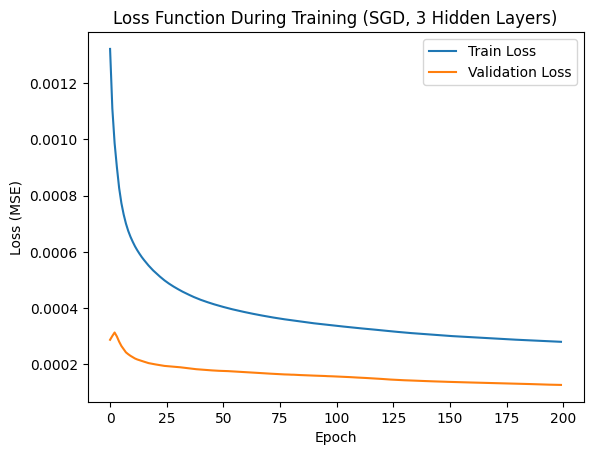

In [31]:
# Jalankan training dengan SGD dan 3 Hidden Layers
weights_input_hidden, bias_hidden_1, weights_hidden_2, bias_hidden_2, weights_hidden_3, bias_hidden_3, weights_hidden_output, bias_output = train_bpnn_sgd(x_train, y_train, x_val, y_val, epochs=200, learning_rate=0.001)

Any NaN in x_test before fixing? False
Any NaN in x_test after fixing? False
Checking y_pred_test and y_test values...
Min y_pred_test: 0.025939728079154498 Max y_pred_test: 0.8179353450444521
Any NaN in predictions? False
Min y_test: 0.015423969649009883 Max y_test: 0.7340292441159947
Any NaN in y_test? False

📊 Evaluasi Model :
✅ Mean Squared Error (MSE): 0.0006717287103238977
✅ Mean Absolute Error (MAE): 0.01476147706444413


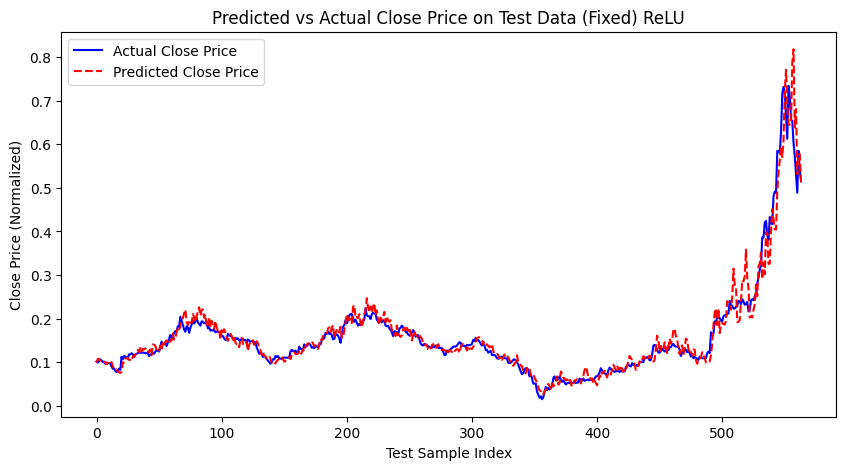

In [38]:
# Fungsi untuk melakukan prediksi dengan model yang telah dilatih
def predict_bpnn(X, weights_input_hidden, bias_hidden_1, weights_hidden_2, bias_hidden_2, 
                 weights_hidden_3, bias_hidden_3, weights_hidden_output, bias_output):
    """Melakukan prediksi menggunakan model BPNN yang telah dilatih"""
    hidden_input_1 = np.dot(X, weights_input_hidden) + bias_hidden_1
    hidden_output_1 = relu(hidden_input_1)

    hidden_input_2 = np.dot(hidden_output_1, weights_hidden_2) + bias_hidden_2
    hidden_output_2 = relu(hidden_input_2)

    hidden_input_3 = np.dot(hidden_output_2, weights_hidden_3) + bias_hidden_3
    hidden_output_3 = relu(hidden_input_3)

    output_input = np.dot(hidden_output_3, weights_hidden_output) + bias_output
    y_pred = linear(output_input)

    return y_pred.flatten()  # Mengembalikan hasil prediksi dalam bentuk array 1D

# Periksa apakah x_test memiliki NaN sebelum melakukan prediksi
print("Any NaN in x_test before fixing?", np.isnan(x_test).any())
x_test = np.nan_to_num(x_test, nan=np.nanmedian(x_test))  # Ganti NaN dengan median dari x_test
print("Any NaN in x_test after fixing?", np.isnan(x_test).any())

# Melakukan prediksi pada data uji
y_pred_test = predict_bpnn(x_test, weights_input_hidden, bias_hidden_1, 
                           weights_hidden_2, bias_hidden_2, 
                           weights_hidden_3, bias_hidden_3, 
                           weights_hidden_output, bias_output)

# Periksa apakah ada NaN dalam hasil prediksi atau target
print("Checking y_pred_test and y_test values...")
print("Min y_pred_test:", np.nanmin(y_pred_test), "Max y_pred_test:", np.nanmax(y_pred_test))
print("Any NaN in predictions?", np.isnan(y_pred_test).any())

print("Min y_test:", np.nanmin(y_test), "Max y_test:", np.nanmax(y_test))
print("Any NaN in y_test?", np.isnan(y_test).any())

# Jika ada NaN atau Inf dalam prediksi, ganti dengan median dari y_test
y_pred_test = np.nan_to_num(y_pred_test, nan=np.nanmedian(y_test))
y_test = np.nan_to_num(y_test, nan=np.nanmedian(y_test))

# Evaluasi Model
mse_test = mse_loss(y_test, y_pred_test)  # Mean Squared Error
mae_test = np.mean(np.abs(y_test - y_pred_test))  # Mean Absolute Error

print(f"\n📊 Evaluasi Model :")
print(f"✅ Mean Squared Error (MSE): {mse_test}")
print(f"✅ Mean Absolute Error (MAE): {mae_test}")

# Plot Prediksi vs Aktual
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual Close Price", color='blue')
plt.plot(y_pred_test, label="Predicted Close Price", color='red', linestyle='dashed')
plt.xlabel("Test Sample Index")
plt.ylabel("Close Price (Normalized)")
plt.title("Predicted vs Actual Close Price on Test Data (Fixed) ReLU")
plt.legend()
plt.show()


📊 Evaluasi Model setelah Denormalisasi:
✅ Mean Squared Error (MSE) dalam skala asli: 10506.577223808266
✅ Mean Absolute Error (MAE) dalam skala asli: 58.37991914026459


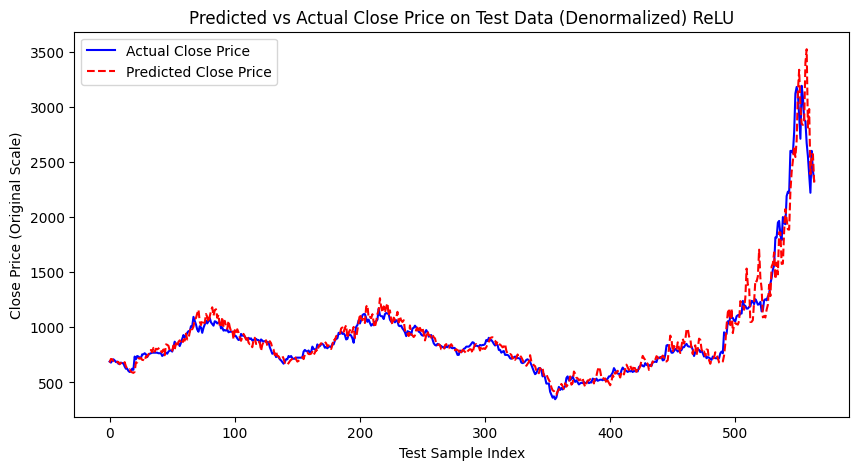

In [36]:
# Buat scaler khusus hanya untuk Close price
close_scaler = MinMaxScaler()
close_scaler.fit(df[['Close']])  # Gunakan data asli sebelum normalisasi untuk mengetahui min-max yang benar

# Denormalisasi nilai prediksi dan nilai aktual
y_pred_test_original = close_scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
y_test_original = close_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Evaluasi Model dalam Skala Asli
mse_test_original = mse_loss(y_test_original, y_pred_test_original)  # MSE dalam skala asli
mae_test_original = np.mean(np.abs(y_test_original - y_pred_test_original))  # MAE dalam skala asli

print(f"\n📊 Evaluasi Model setelah Denormalisasi:")
print(f"✅ Mean Squared Error (MSE) dalam skala asli: {mse_test_original}")
print(f"✅ Mean Absolute Error (MAE) dalam skala asli: {mae_test_original}")

# Plot Prediksi vs Aktual dalam Skala Asli
plt.figure(figsize=(10,5))
plt.plot(y_test_original, label="Actual Close Price", color='blue')
plt.plot(y_pred_test_original, label="Predicted Close Price", color='red', linestyle='dashed')
plt.xlabel("Test Sample Index")
plt.ylabel("Close Price (Original Scale)")
plt.title("Predicted vs Actual Close Price on Test Data (Denormalized) ReLU")
plt.legend()
plt.show()
